In [1]:
# sys.path manipulation to include parent directory
import sys
from pathlib import Path

parent_folder = str(Path.cwd().parent)
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

# Importing necessary libraries and modules
import pandas as pd
from src.config import ApplicationConfig

# Import the custom visualization module
from src.data_plotter import DataPlotter

In [2]:
raw_df = pd.read_csv(ApplicationConfig().data_path)
display(raw_df.head())

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,"44,2352","47,6573","46,4418","64,8203","66,4545","44,4832",False
1,2,2,4,"60,8072","63,1721","62,0060","80,7144","81,2464","60,2287",False
2,3,2,1,"79,0275","83,0322","82,6421","98,2544","98,7852","80,9935",False
3,4,2,3,"79,7162","100,5086","122,3623","121,3634","118,6525","80,3156",False
4,5,2,5,"39,9891","51,7648","42,5143","61,0379","50,7165","64,2452",False


# 1. Dataset overview

Before diving into data analysis, it is important to understand and document the dataset’s variables. This step supports a clearer understanding of the problem and aids in defining the data schema when working with databases. Additionally, it guides the exploratory analysis by clarifying the meaning and interpretation of each variable.

Briefly, the dataset represents the monitoring of a Floating Production Storage and Offloading (FPSO) equipment unit across a sequence of operational cycles, with the goal of identifying and predicting equipment failures. It includes setup configurations, sensor readings such as temperature, pressure, and frequency, as well as a target variable indicating whether the equipment was in a failure state.

| Variable          | Type          | Data Type |Interpretation                                                                  |
| ----------------- | ------------- | --------- |------------------------------------------------------------------------------- |
| Cycle             | Temporal      | Numeric (int) |Represents the passage of time in operational cycles |
| Preset\_1         | Setup | Categorical (int) | Operational configuration parameter of the equipment                      |
| Preset\_2         | Setup | Categorical (int) |Operational configuration parameter of the equipment                                                         |
| Temperature       | Sensor        | Numeric (float) |Temperature measured in a given operation cycle                        |
| Vibrations\_X/Y/Z | Sensor        | Numeric (float) |Vibration measurements along the three spatial axes in a given operation cycle                            |
| Frequency         | Sensor        | Numeric (float) |Frequency measured in a given operation cycle                             |
| Fail              | Target        | Binary (bool) |Indicates whether the equipment is in a failure state (True) or normal (False)         |


# 2. Data Cleaning

Inspecting the raw dataset, it is possible to verify that the columns data types are not properly defined.

In [3]:
# Displaying the data types of the DataFrame
raw_df.dtypes

Cycle           int64
Preset_1        int64
Preset_2        int64
Temperature    object
Pressure       object
VibrationX     object
VibrationY     object
VibrationZ     object
Frequency      object
Fail             bool
dtype: object

## 2.1 Data Types

The float numeric columns are being interpreted as text because they use commas as decimal separators. To ensure proper numerical analysis in Python, these commas should be replaced with dots, and the columns should be converted to float data types.

In [4]:
# Function to convert object columns with commas to float
def parse_comma_decimal_series(series: pd.Series) -> pd.Series:
    return series.str.replace(',', '.').astype('float64')

# Function to get object columns with commas in their values
def find_comma_decimal_columns(df: pd.DataFrame) -> list:
    """
    Returns a list of columns that contain commas in their values.
    """
    return [
        col for col in df.columns
        if df[col].dtype == 'object' and df[col].str.contains(',').any()
    ]

def df_convert_comma_decimals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adjusts the data types of columns in the DataFrame.
    Converts object columns with commas to float.
    """
    obj_columns = find_comma_decimal_columns(df)
    for col in obj_columns:
        df[col] = parse_comma_decimal_series(df[col])
    return df

In [5]:
obj_columns = find_comma_decimal_columns(raw_df)
print(f"Columns with commas: {obj_columns}")

Columns with commas: ['Temperature', 'Pressure', 'VibrationX', 'VibrationY', 'VibrationZ', 'Frequency']


In [6]:
# Applying the conversion function to the DataFrame
df = df_convert_comma_decimals(raw_df)

In [7]:
# New data types of the DataFrame
print(df.dtypes)
display(df.head())

Cycle            int64
Preset_1         int64
Preset_2         int64
Temperature    float64
Pressure       float64
VibrationX     float64
VibrationY     float64
VibrationZ     float64
Frequency      float64
Fail              bool
dtype: object


,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,False
1,2,2,4,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,False
2,3,2,1,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,False
3,4,2,3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,False
4,5,2,5,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,False


## 2.2 Null values and index

In [8]:
# Checking for null values in the DataFrame
df.isnull().sum()

Cycle          0
Preset_1       0
Preset_2       0
Temperature    0
Pressure       0
VibrationX     0
VibrationY     0
VibrationZ     0
Frequency      0
Fail           0
dtype: int64

No null values were found

In order to allow better handling of the time dimension on the dataset, the variable **Cycle** will be used as index.

In [9]:
# Define Cycle as the index
df.set_index('Cycle', inplace=True)

With all data cleaning pendencies solved, it is now possible to analyze the general statistics of the dataset.

In [10]:
# Export processed DataFrame to CSV
df.to_csv(ApplicationConfig().processed_data_path, index=True)

### Key Findings of Section 2: Data Cleaning

- **Data Types Correction:** Several numeric columns (e.g., Temperature, Pressure, VibrationX/Y/Z, Frequency) were initially read as text due to the use of commas as decimal separators. These were successfully converted to proper float types, enabling numerical analysis.
- **Null Values:** The dataset contains no missing values, ensuring completeness for analysis.
- **Indexing:** The 'Cycle' column was set as the DataFrame index, reflecting the temporal nature of the data and facilitating time-based operations.

# 3. Exploratory Data Analysis (EDA)

In this step, the main goal is to perform an initial examination of the dataset to understand the overall behavior of the variables. This may reveal general patterns, potential anomalies, and relationships between the equipment setup parameters and sensor measurements. It may also provide early insights into possible causes of equipment failures in the FPSO system.

## 3.1 Target variable analysis

### 3.1.1 Failure distribution

Fail
False    734
True      66
Name: count, dtype: int64


Fail
False    91.75
True      8.25
Name: proportion, dtype: float64


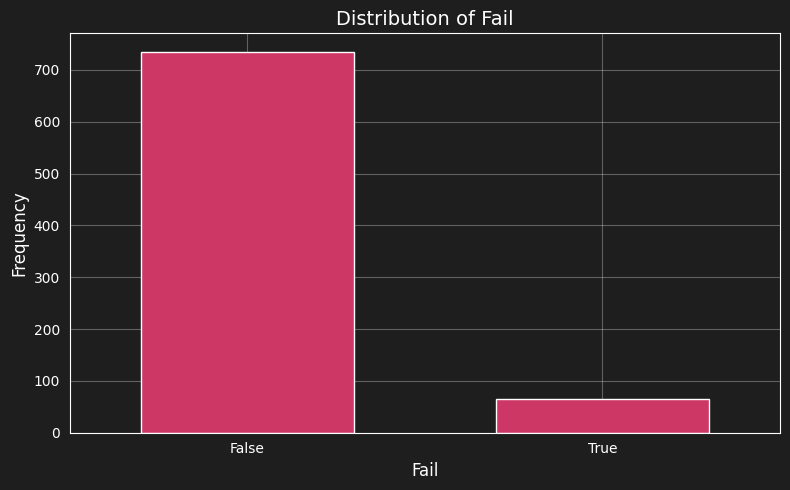

In [11]:
print(df['Fail'].value_counts())
print('\n')
print(df['Fail'].value_counts(normalize=True)*100)

fig = DataPlotter(figsize=(8,5)).plot_histogram(df, 'Fail')

According to the data, it is possible to affirm that the equipment was in a failure state for approximately 8.25% of the time or 66 operation cycles.

As expected, the target variable is imbalanced, since equipment failure is a relatively rare event. However, the failure state is precisely what needs to be predicted. For this reason, it is essential to understand the equipment’s behavior during failure, despite the smaller amount of available data.

### 3.1.2 Behavior of sensored variables during failures

First, the numeric variables, such as Temperature and Pressure, will be analyzed. This section aims to identify significant differences in their values between normal and failure states.

In [12]:
# Grouping by 'Fail' and aggregating statistics
stats_by_failure_state = df.groupby('Fail').agg({
    'Temperature': ['mean', 'median','max', 'min'],
    'VibrationX': ['mean', 'median','max', 'min'],
    'VibrationY': ['mean', 'median','max', 'min'],
    'VibrationZ': ['mean', 'median','max', 'min'],
    'Frequency': ['mean', 'median','max', 'min']
})

display(stats_by_failure_state)

Temperature                               VibrationX            \
             mean    median       max      min        mean    median   
Fail                                                                   
False   67.176883  64.81490  255.6078   2.0894   71.494801  66.35860   
True    92.469126  90.92895  150.8803  48.0920  100.167188  98.04375   

                          VibrationY                                \
            max      min        mean     median       max      min   
Fail                                                                 
False  230.8611   3.8463   68.318454   63.51685  176.1979  10.0577   
True   200.7496  20.1205  122.481161  122.11510  193.5699  50.4818   

       VibrationZ                               Frequency                     \
             mean    median       max      min       mean   median       max   
Fail                                                                           
False   68.796673  65.00595  230.9511  18.7842  65.382993  62.6873  158.8117   
True   106.003211  99.66940  200.2427  20.5226  99.812742  99.2127  178.0903   

                
           min  
Fail            
False   4.3801  
True   48.9238

All five sensor-based variables exhibit higher descriptive statistics during the failure state. The boxplots below visually illustrate this finding. statiscs during the fail state. Below, a series of boxplots represent this find visually.

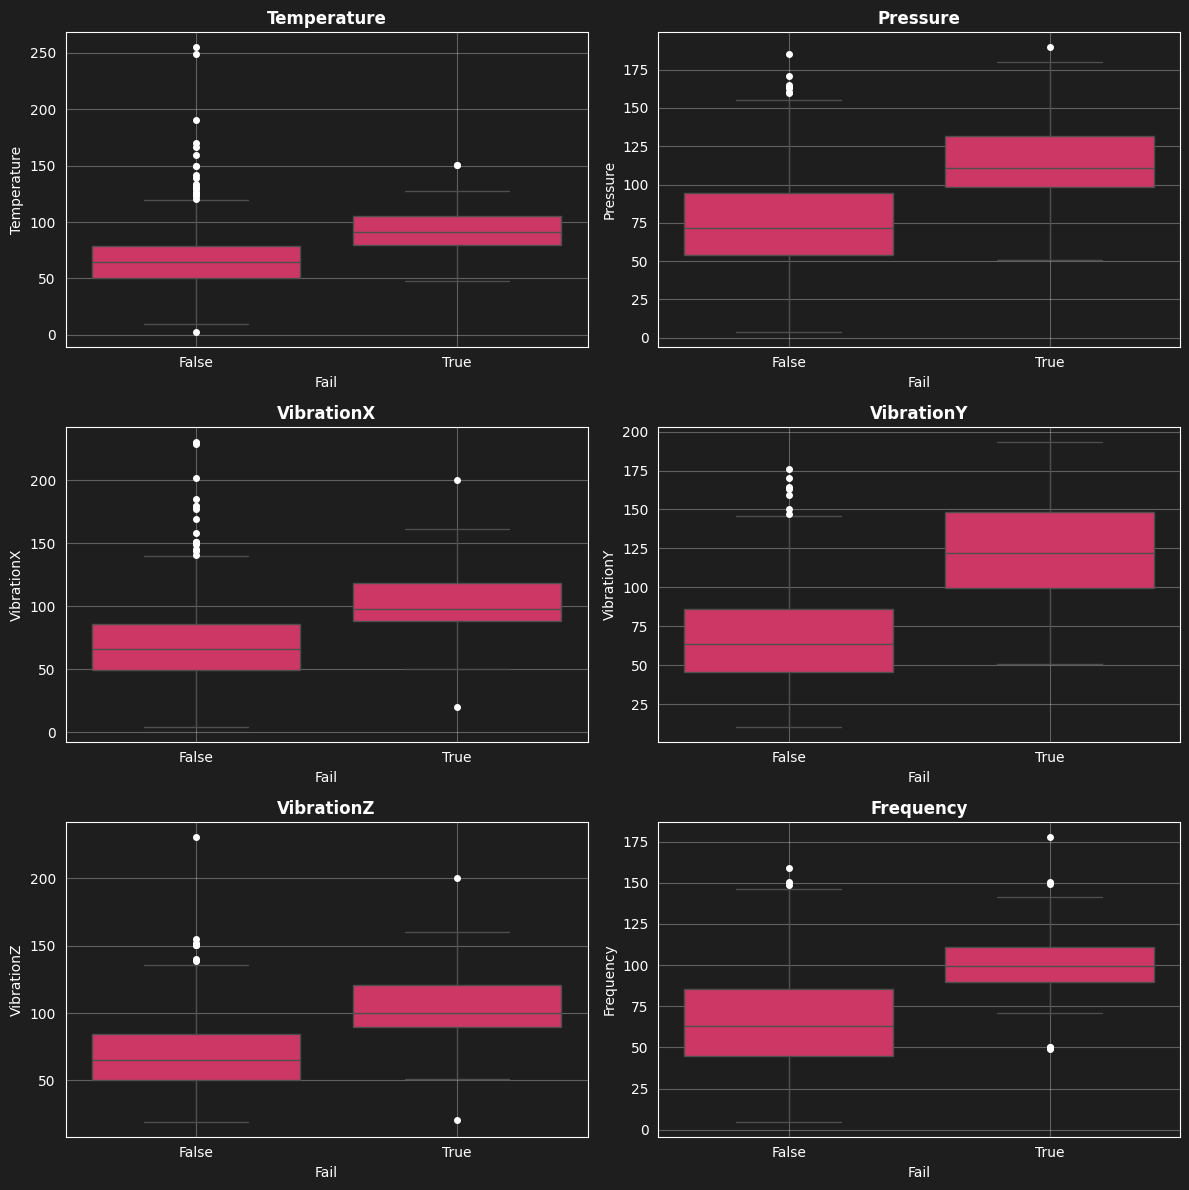

In [13]:
# Boxplot for each numeric column grouped by 'Fail'
# This will help visualize the distribution of each feature for both failure states
fig = DataPlotter().plot_multiple_boxplots(df, df.select_dtypes(float).columns.tolist(), 'Fail')

It becomes evident that all numeric variables tend to be higher when the equipment is in a failure state. This suggests that increasing values in these variables during operation cycles may be indicators of a possible future equipment failure. Additionally, the distributions of all variables show minimal overlap between normal and failure states, indicating strong predictive potential.

Among them, **VibrationY** and **Pressure** demonstrate the most significant differences between normal and failure conditions. This shows their potential importance in failure detection and suggests they may play a critical role in the feature importance analysis of the machine learning model to be developed.

One simple way to quantify these difference is calculating the mean differences of each variable in normal and failure state.

In [14]:
from typing import List

def mean_difference_by_target(df: pd.DataFrame, columns: List[str], target: str = 'Fail') -> pd.Series:
    """
    Calculates the mean difference for the specified columns between True and False states of the target variable.

    Args:
        df (pd.DataFrame): The dataframe containing the data.
        columns (list): List of column names to calculate mean difference for.
        target (str): The binary target column name.

    Returns:
        pd.Series: Mean difference (True - False) for each column.
    """
    means_true = df[df[target] == True][columns].mean()
    means_false = df[df[target] == False][columns].mean()
    return means_true - means_false

In [15]:
# Calculate mean differences for float columns by target and sort results
mean_difference_by_target(df, df.select_dtypes(float).columns.tolist(), 'Fail').sort_values(ascending=False)

VibrationY     54.162707
Pressure       40.789751
VibrationZ     37.206537
Frequency      34.429749
VibrationX     28.672387
Temperature    25.292243
dtype: float64

Once again, the data reveals a significant increase in sensored variables during equipment failures. The mean **VibrationY** is approximately 54 units higher and mean **Pressure** is 40 units higher when the equipment is in a failure state.

### 3.1.3 Distribution of setup parameters during failures

The setup variables Preset_1 and Preset_2 define how the equipment is configured during an operation cycle. Analyzing their relationship with failure occurrences is essential to identify configuration combinations that are more likely to result in failures.

Considering the entire dataset, both variables exhibit a well-balanced distribution across their available values. Preset_1 has three unique values, each used in approximately one-third of the operation cycles. Similarly, Preset_2 has eight possible values, all of which appear with roughly equal frequency throughout the data collection period.

In [16]:
# Preset_1 and Preset_2 distributions
print(df['Preset_1'].value_counts(normalize=True)*100)
print(df['Preset_2'].value_counts(normalize=True)*100)

Preset_1
2    35.125
1    33.000
3    31.875
Name: proportion, dtype: float64
Preset_2
7    13.625
6    12.625
2    12.625
3    12.625
5    12.500
8    12.500
1    11.875
4    11.625
Name: proportion, dtype: float64


The histograms below reinforces the above interpretation.

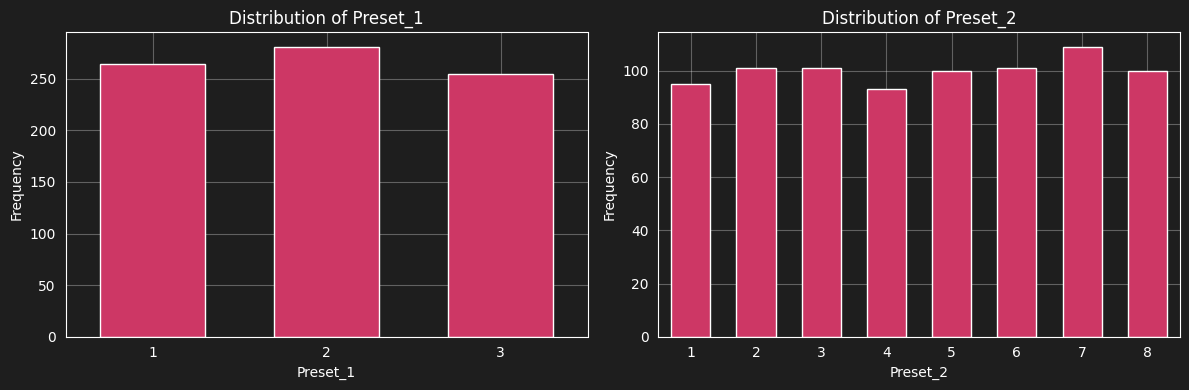

In [17]:
fig = DataPlotter().plot_multiple_histograms(df, ['Preset_1','Preset_2'])

On the other hand, when isolating the operation cycles with failure, certain setup parameters appear more frequently, such as values 1 and 2 for **Preset_1**, and 1 and 5 for **Preset_2**. Conversely, parameter 4 on **Preset_2** is relatively uncommon in failure events.

In [18]:
# Preset_1 and Preset_2 distributions considering only failure events
print(df.query('Fail == True')['Preset_1'].value_counts(normalize=True)*100)
print(df.query('Fail == True')['Preset_2'].value_counts(normalize=True)*100)

Preset_1
1    40.909091
2    31.818182
3    27.272727
Name: proportion, dtype: float64
Preset_2
5    18.181818
1    16.666667
2    13.636364
6    13.636364
7    13.636364
8    10.606061
3     9.090909
4     4.545455
Name: proportion, dtype: float64


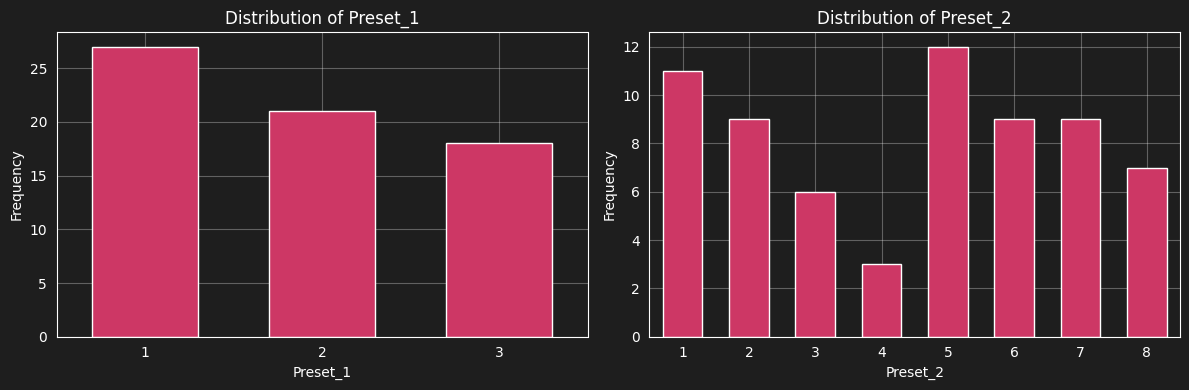

In [19]:
# Plotting histograms for Preset_1 and Preset_2 for failure events
fig = DataPlotter().plot_multiple_histograms(df.query("Fail == True"), ['Preset_1','Preset_2'])

Taking it a step further, specific combinations of **Preset_1** and **Preset_2** configurations may be correlated with failure events. To visualize this relationship, a heatmap can be used to show how the proportion of failures varies across different equipment setup combinations.

In [20]:
# Grouping by Preset_1 and calculating failure rate and number of cycles with failure
print(df.groupby(['Preset_1']).agg({'Fail': ['mean', 'sum']}).rename(columns={'mean': 'Failure Rate', 'sum': 'Cycles with Failure'}))
print('\n')
# Grouping by Preset_2 and calculating failure rate and number of cycles with failure
print(df.groupby(['Preset_2']).agg({'Fail': ['mean', 'sum']}).rename(columns={'mean': 'Failure Rate', 'sum': 'Cycles with Failure'}))

                 Fail                    
         Failure Rate Cycles with Failure
Preset_1                                 
1            0.102273                  27
2            0.074733                  21
3            0.070588                  18


                 Fail                    
         Failure Rate Cycles with Failure
Preset_2                                 
1            0.115789                  11
2            0.089109                   9
3            0.059406                   6
4            0.032258                   3
5            0.120000                  12
6            0.089109                   9
7            0.082569                   9
8            0.070000                   7


**Preset_1**
- Preset_1=1 has a higher failure rate (~10%) in comparison with the other two options.

**Preset_2**
- Preset_2=5 and Preset_2=1 appears to be risky, both with approximately 12% of failure rate.
- Preset_2=4 could be considered the safest setting, with only 3% of failure rate. 

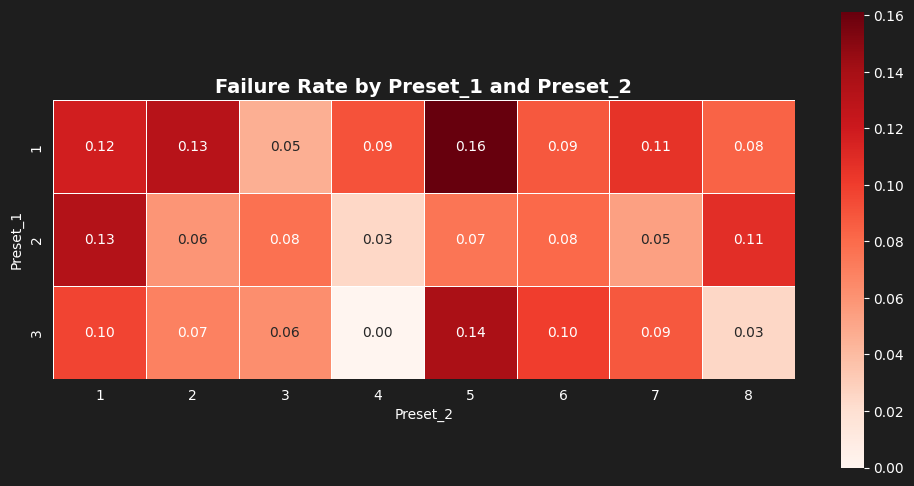

In [21]:
# Heatmap plotting failure rates by Preset_1 and Preset_2
fig = DataPlotter().plot_failure_rate_heatmap(df, row_var='Preset_1', col_var='Preset_2', target_var='Fail')

The heatmap reveals that certain equipment setups stand out with a noticeably higher occurrence of failures.

**Configurations with high failure rates**:
- Preset_1=1, Preset_2=5: Highest failure rate at 16%, almost double of the mean failure rate (8.25%).
- Preset_1=3, Preset_2=5: Second highest at 14%
- Preset_1=1, Preset_2=2: Third highest at 13%

**Configurations with low failure rates**:
- Preset_1=3, Preset_2=4: Zero failures (safest combination)
- Preset_1=2, Preset_2=4: Only 3% failure rate

Without specific knowledge of how the **Preset_1** and **Preset_2** parameters control equipment operation, it is difficult to recommend direct actions to minimize failure risk on the FPSO.

Nonetheless, based on the analyzed data, it is advisable to avoid configurations associated with high failure rates, especially during critical operations or peak production periods. As a safer alternative, combinations such as Preset_1 = 3 and Preset_2 = 4, which showed lower failure occurrences, could be prioritized when possible.

These critical equipment configurations should be closely monitored alongside sensor-based variables. The combination of high-risk setups with increases in variables such as vibration and pressure may serve as early warning signals of equipment failure.

### 3.1.4 Failure event analysis

Another important aspect of this study is identifying distinct failure events and analyzing them in terms of their duration, causes, and associated variable behavior.

The first step is to find these events and categorize them on the dataset.

In [ ]:
def find_failure_starts(fail_series: pd.Series) -> List[int]:
    """
    Counts the number of times a failure starts (i.e., transitions from False to True) in a boolean Series.

    Args:
        fail_series (pd.Series): A pandas Series of boolean values indicating failure state over time.

    Returns:
        list: List of cycles where transitions from False to True occured.
    """
    # Check if the input series is of boolean dtype
    if fail_series.dtype != bool:
        raise ValueError("Input series must be of boolean dtype.")
    
    # Use shift to 'move' rows one position down and verify previous state
    previous_state = fail_series.shift(1, fill_value=False)

    # Invert previous state to find transitions from False to True
    previous_state = ~previous_state

    # Compare the previous state with the current state to find transitions
    transition_starts = previous_state & fail_series

    return list(transition_starts[transition_starts == True].index)

def find_failure_stops(fail_series: pd.Series) -> List[int]:
    """
    Counts the number of times a failure stops (i.e., transitions from True to False) in a boolean Series.

    Args:
        fail_series (pd.Series): A pandas Series of boolean values indicating failure state over time.

    Returns:
        List[int]: List of cycles ids where transitions from True to False occured.
    """
    # Check if the input series is of boolean dtype
    if fail_series.dtype != bool:
        raise ValueError("Input series must be of boolean dtype.")
    
    # Use shift to 'move' rows one position down and verify previous state
    previous_state = fail_series.shift(1, fill_value=False)

    # Compare the previous state with the current state to find transitions
    transition_stops = previous_state & ~fail_series

    return list(transition_stops[transition_stops == True].index)


In [24]:
# Find operation cycles where failures start and stop
failures_starts = find_failure_starts(df['Fail'])
failures_stops = find_failure_stops(df['Fail'])

In [25]:
failures_starts[0]

13

In [50]:
n = len(failures_starts)
failure_duration = df['Fail'].sum()

print(f"Total duration of failure state: {failure_duration} cycles")
print(f"Total number of failure starts: {n}")
print(f"Mean failure state duration per occurence: {failure_duration / n} cycles")

Total duration of failure state: 66 cycles
Total number of failure starts: 10
Mean failure state duration per occurence: 6.6 cycles


In [51]:
def label_failures(df: pd.DataFrame, target_column: str = 'Fail', fail_index_column: str = 'Fail_index') -> pd.DataFrame:
    """
    Labels the failure periods in the DataFrame with a unique index for each failure.

    Args:
        df (pd.DataFrame): DataFrame containing the failure data with 'Fail' column.

    Returns:
        pd.DataFrame: DataFrame with an additional 'Fail_index' column indicating failure periods.
    """
    # Find start and stop indices of failures
    failures_starts = find_failure_starts(df[target_column])
    failures_stops = find_failure_stops(df[target_column])

    if len(failures_starts) > len(failures_stops):
        failures_stops.append(df.index[-1])  # Append the last index if stops are fewer than starts
    if len(failures_starts) < len(failures_stops):
        failures_starts.append(df.index[0])  # Append the first index if starts are fewer than stops

    # Initialize a new column for failure indices
    df[fail_index_column] = 0

    # Loop through each failure period and assign an index
    for i, (start, stop) in enumerate(zip(failures_starts, failures_stops)):
        print(f"Failure {i+1} start at operation cycle: {start}")
        print(f"Failure {i+1} stop at operation cycle: {stop}")

        # Assigning a failure index to the DataFrame for each failure period
        mask = (df.index >= start) & (df.index < stop)
        df.loc[mask, 'Fail_index'] = i + 1

    return df

In [52]:
df = label_failures(df, target_column='Fail', fail_index_column='Fail_index')

Failure 1 start at operation cycle: 13
Failure 1 stop at operation cycle: 14
Failure 2 start at operation cycle: 157
Failure 2 stop at operation cycle: 160
Failure 3 start at operation cycle: 163
Failure 3 stop at operation cycle: 166
Failure 4 start at operation cycle: 263
Failure 4 stop at operation cycle: 266
Failure 5 start at operation cycle: 270
Failure 5 stop at operation cycle: 272
Failure 6 start at operation cycle: 415
Failure 6 stop at operation cycle: 433
Failure 7 start at operation cycle: 538
Failure 7 stop at operation cycle: 547
Failure 8 start at operation cycle: 550
Failure 8 stop at operation cycle: 555
Failure 9 start at operation cycle: 700
Failure 9 stop at operation cycle: 714
Failure 10 start at operation cycle: 793
Failure 10 stop at operation cycle: 800


In [53]:
df.head(15)

,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,Fail_index
Cycle,,,,,,,,,,
1,3,6,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,False,0
2,2,4,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,False,0
3,2,1,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,False,0
4,2,3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,False,0
5,2,5,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,False,0
6,1,2,58.3361,64.4264,56.4792,78.6237,65.9115,78.8862,False,0
7,1,3,77.9378,83.1467,77.8006,109.6790,86.2307,99.6812,False,0
8,1,4,78.5635,130.0899,110.4799,130.9970,85.2186,98.4674,False,0
9,3,7,77.4862,104.4630,77.3904,159.4235,115.2119,98.9003,False,0


In [54]:
df.to_csv(ApplicationConfig().processed_data_path, index=True)

With the new label added to the dataset, it is now possible to identify the failure events that lasted the most operation cycles. These longer events may indicate more critical or severe failures in the equipment.

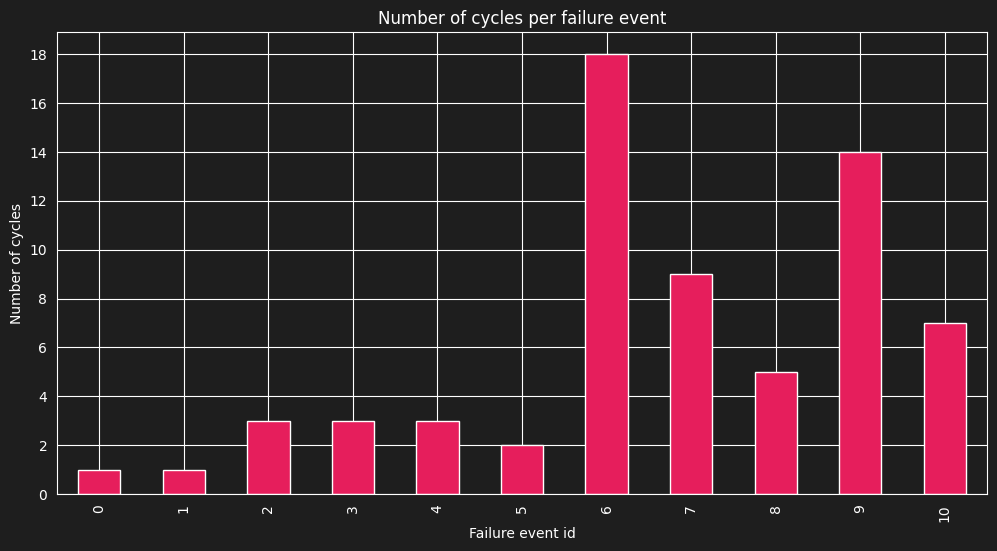

In [55]:
from matplotlib.ticker import MaxNLocator
from matplotlib import pyplot as plt

# Plotting the number of cycles per failure event
failures = df.query('Fail == True').groupby('Fail_index').size()
ax = failures.plot(kind='bar', figsize=(12, 6), title='Number of cycles per failure event')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Number of cycles')
ax.set_xlabel('Failure event id')

plt.show()

It is now clear that failure events 6 through 10 lasted significantly longer than the first five occurrences. These extended events will be further analyzed in detail to better understand their characteristics and potential causes.

In [56]:
failures_summary = df[df['Fail_index'] > 0].groupby('Fail_index').agg({
    'Temperature': ['mean', 'max', 'min'],
    'VibrationX': ['mean', 'max', 'min'],
    'VibrationY': ['mean', 'max', 'min'],
    'VibrationZ': ['mean', 'max', 'min'],
    'Frequency': ['mean', 'max', 'min'],
    'Fail': 'count',  # this is the duration in cycles
    'Preset_1': lambda x: x.iloc[0],  # value at start of failure
    'Preset_2': lambda x: x.iloc[0],
    # add others as needed
})

In [57]:
failures_summary = df.groupby('Fail').agg({
    'Temperature': ['mean', 'median','max', 'min'],
    'VibrationX': ['mean', 'median','max', 'min'],
    'VibrationY': ['mean', 'median','max', 'min'],
    'VibrationZ': ['mean', 'median','max', 'min'],
    'Frequency': ['mean', 'median','max', 'min']
    # add others as needed
})

In [58]:
failures_summary

Temperature                               VibrationX            \
             mean    median       max      min        mean    median   
Fail                                                                   
False   67.176883  64.81490  255.6078   2.0894   71.494801  66.35860   
True    92.469126  90.92895  150.8803  48.0920  100.167188  98.04375   

                          VibrationY                                \
            max      min        mean     median       max      min   
Fail                                                                 
False  230.8611   3.8463   68.318454   63.51685  176.1979  10.0577   
True   200.7496  20.1205  122.481161  122.11510  193.5699  50.4818   

       VibrationZ                               Frequency                     \
             mean    median       max      min       mean   median       max   
Fail                                                                           
False   68.796673  65.00595  230.9511  18.7842  65.382993  62.6873  158.8117   
True   106.003211  99.66940  200.2427  20.5226  99.812742  99.2127  178.0903   

                
           min  
Fail            
False   4.3801  
True   48.9238

In [59]:
print(f'Total Preset_1 unique_values: {df['Preset_1'].nunique()} - {sorted(df["Preset_1"].unique())}')
print('\n')
print(df['Preset_1'].value_counts())  # Descriptive statistics
print('\n')
print(df['Preset_1'].value_counts(normalize=True))  # Descriptive statistics

Total Preset_1 unique_values: 3 - [np.int64(1), np.int64(2), np.int64(3)]


Preset_1
2    281
1    264
3    255
Name: count, dtype: int64


Preset_1
2    0.35125
1    0.33000
3    0.31875
Name: proportion, dtype: float64


In [60]:
df['Preset_1'].value_counts(normalize=True)  # Descriptive statistics

Preset_1
2    0.35125
1    0.33000
3    0.31875
Name: proportion, dtype: float64

In [61]:
df['Fail'].value_counts(normalize=True)  # Descriptive statistics

Fail
False    0.9175
True     0.0825
Name: proportion, dtype: float64

In [62]:
df['Preset_2'].value_counts(normalize=True)  # Descriptive statistics

Preset_2
7    0.13625
6    0.12625
2    0.12625
3    0.12625
5    0.12500
8    0.12500
1    0.11875
4    0.11625
Name: proportion, dtype: float64

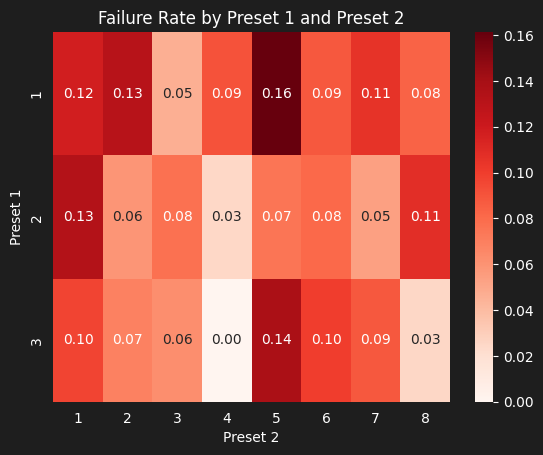

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by presets and calculate failure rate
failure_rate = df.groupby(['Preset_1', 'Preset_2'])['Fail'].mean().unstack()

# Plot as heatmap
sns.heatmap(failure_rate, annot=True, cmap='Reds', fmt=".2f")
plt.title("Failure Rate by Preset 1 and Preset 2")
plt.ylabel('Preset 1')
plt.xlabel('Preset 2')
plt.show()

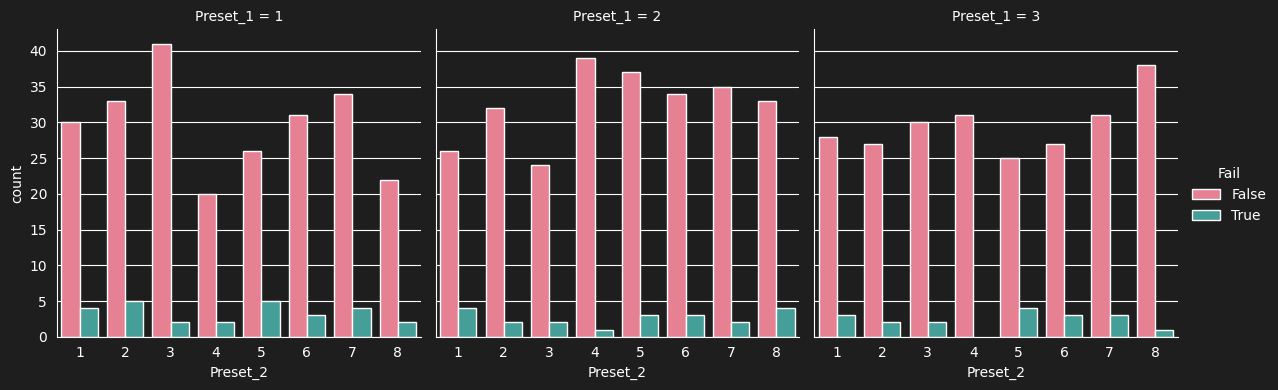

In [64]:
sns.catplot(data=df, x='Preset_2', hue='Fail', col='Preset_1',
            kind='count', col_wrap=3, height=4, aspect=1)
plt.show()

In [65]:
def get_pre_failure_buffer(df: pd.DataFrame, 
                          failure_indices: List[int], 
                          buffer_size: int,
                          exclude_failure_cycles: bool = True) -> pd.DataFrame:
    """
    Extrai os ciclos anteriores às falhas para análise de padrões pré-falha.
    
    Args:
        df (pd.DataFrame): DataFrame com os dados
        failure_indices (List[int]): Lista dos índices onde ocorreram falhas
        buffer_size (int): Número de ciclos anteriores à falha para incluir
        exclude_failure_cycles (bool): Se True, exclui ciclos que já estão em falha
        
    Returns:
        pd.DataFrame: DataFrame contendo apenas os ciclos do buffer pré-falha
    """
    buffer_indices = []

    buffer_df = df.copy()
    
    for failure_idx in failure_indices:
        # Calcula o range do buffer anterior à falha
        start_buffer = failure_idx - buffer_size
        end_buffer = failure_idx - 1  # Não inclui o ciclo de falha
        
        # Garante que não vai além do início do dataset
        start_buffer = max(start_buffer, df.index.min())

        failure_event = failure_indices.index(failure_idx)

        buffer_df.loc[start_buffer:end_buffer, 'Fail_index'] = failure_event + 1
        
        # Adiciona os índices do buffer se eles existem no dataset
        for idx in range(start_buffer, end_buffer + 1):
            if idx in buffer_df.index:
                # Se exclude_failure_cycles=True, só adiciona se não estiver em falha
                if exclude_failure_cycles:
                    if not buffer_df.loc[idx, 'Fail']:
                        buffer_indices.append(idx)
                else:
                    buffer_indices.append(idx)
    
    # Remove duplicatas e ordena
    buffer_indices = sorted(list(set(buffer_indices)))
    
    # Retorna o subset do DataFrame
    return buffer_df.loc[buffer_indices].copy()

In [66]:
buffer = get_pre_failure_buffer(df, failures_starts, buffer_size=5, exclude_failure_cycles=True)

In [70]:
print("\n2. PRE-FAILURE CONFIGURATION PATTERNS:")
print("   Configuration usage in 5 cycles before failures:")
print("   Preset_1 distribution:")
buffer_preset1 = buffer['Preset_1'].value_counts(normalize=True).sort_index()
normal_preset1 = df[df['Fail']==False]['Preset_1'].value_counts(normalize=True).sort_index()
for preset in buffer_preset1.index:
    print(f"     Preset_1={preset}: {buffer_preset1[preset]:.1%} (pre-failure) vs {normal_preset1[preset]:.1%} (normal)")



2. PRE-FAILURE CONFIGURATION PATTERNS:
   Configuration usage in 5 cycles before failures:
   Preset_1 distribution:
     Preset_1=1: 31.1% (pre-failure) vs 32.3% (normal)
     Preset_1=2: 37.8% (pre-failure) vs 35.4% (normal)
     Preset_1=3: 31.1% (pre-failure) vs 32.3% (normal)


In [71]:
print("\n2. PRE-FAILURE CONFIGURATION PATTERNS:")
print("   Configuration usage in 5 cycles before failures:")
print("   Preset_2 distribution:")
buffer_preset2 = buffer['Preset_2'].value_counts(normalize=True).sort_index()
normal_preset2 = df[df['Fail']==False]['Preset_2'].value_counts(normalize=True).sort_index()
for preset in buffer_preset2.index:
    print(f"     Preset_2={preset}: {buffer_preset2[preset]:.1%} (pre-failure) vs {normal_preset2[preset]:.1%} (normal)")



2. PRE-FAILURE CONFIGURATION PATTERNS:
   Configuration usage in 5 cycles before failures:
   Preset_2 distribution:
     Preset_2=1: 2.2% (pre-failure) vs 11.4% (normal)
     Preset_2=2: 17.8% (pre-failure) vs 12.5% (normal)
     Preset_2=3: 15.6% (pre-failure) vs 12.9% (normal)
     Preset_2=4: 6.7% (pre-failure) vs 12.3% (normal)
     Preset_2=5: 20.0% (pre-failure) vs 12.0% (normal)
     Preset_2=6: 4.4% (pre-failure) vs 12.5% (normal)
     Preset_2=7: 17.8% (pre-failure) vs 13.6% (normal)
     Preset_2=8: 15.6% (pre-failure) vs 12.7% (normal)


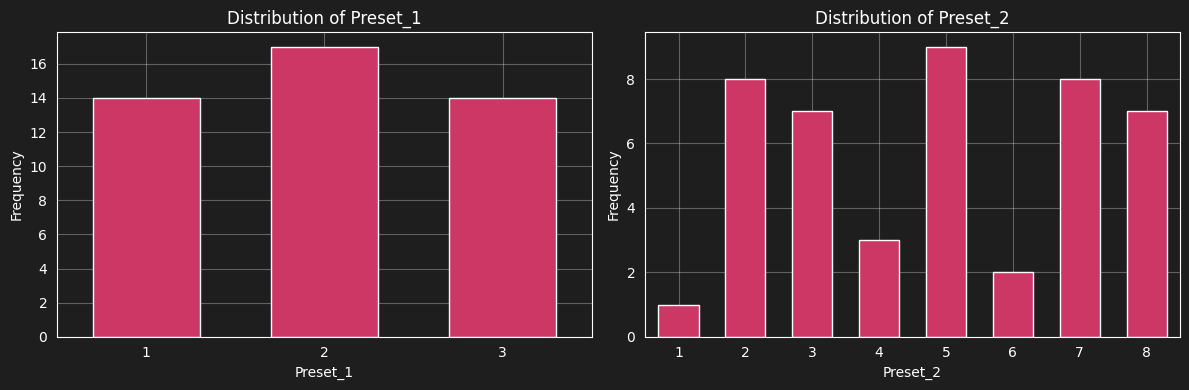

In [68]:
fig = DataPlotter().plot_multiple_histograms(buffer, ['Preset_1','Preset_2'])